Prokaryotic ZOTUs: 5892
OTU matrix: (52, 5892)
Rare ZOTUs (≤1% max): 321
Rare OTU matrix:      (52, 321)

Alpha diversity (rare taxa) computed for 52 samples

Mean values by field:
          Richness  Shannon  Simpson  Evenness
Field                                         
Eureka      21.167    2.332    0.744     0.875
Ibex        31.800    3.438    0.967     1.000
Mesquite     4.444    1.232    0.612     0.833

Kruskal-Wallis p values (rare taxa):
  Richness: 0.0006
  Evenness: 0.8543
  Shannon:  0.0006
  Simpson:  0.0006


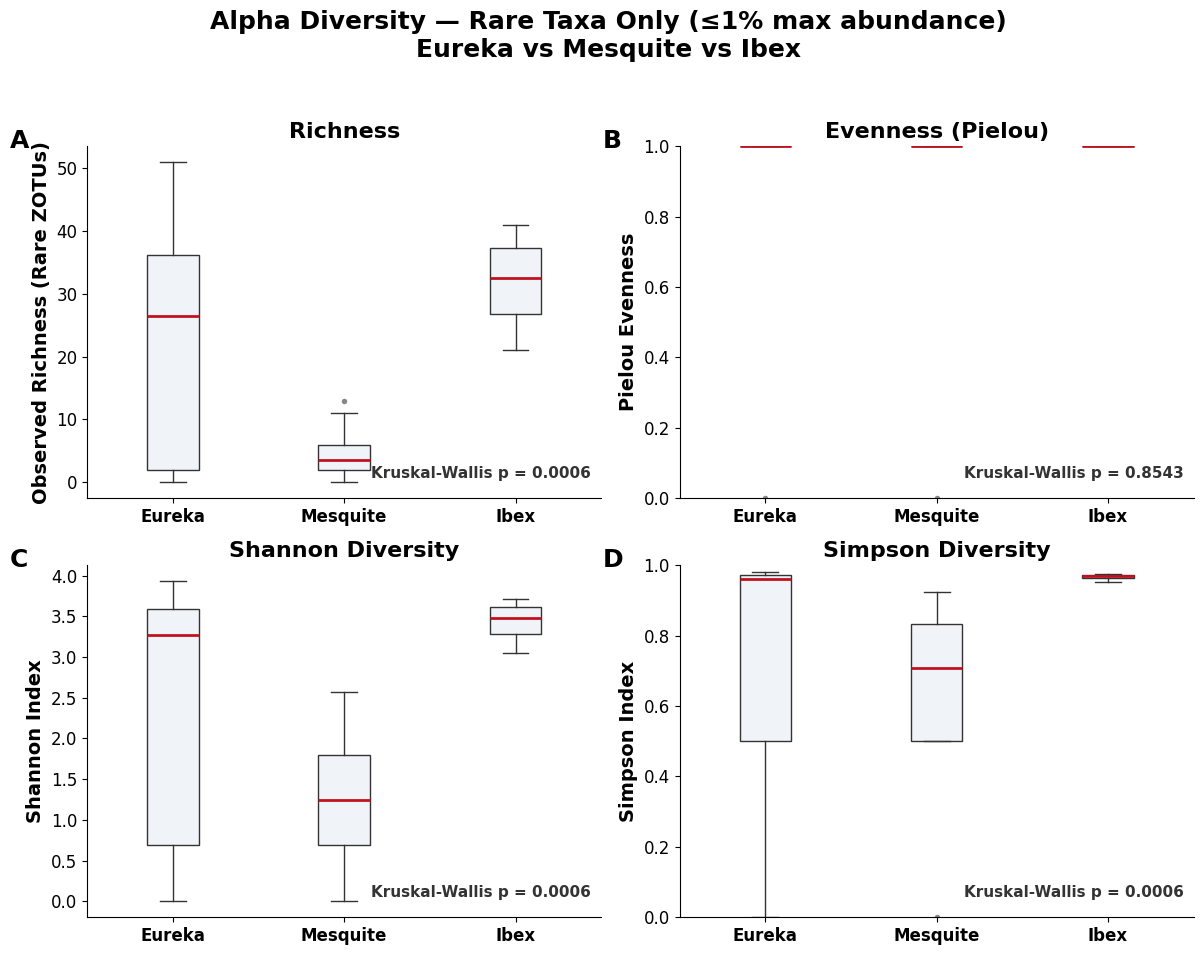

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# LOAD COUNT FILE
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER PROKARYOTES
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape}")

# ============================
# IDENTIFY RARE ZOTUs
# rare = never exceeds 1% in any single sample
# ============================
zotu_max   = otu.max(axis=0)
rare_zotus = zotu_max[zotu_max <= 1.0].index
otu_rare   = otu[rare_zotus].copy()

print(f"Rare ZOTUs (≤1% max): {len(rare_zotus)}")
print(f"Rare OTU matrix:      {otu_rare.shape}")

# ============================
# ALPHA DIVERSITY FUNCTIONS
# computed on rare ZOTU counts only
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

# ============================
# COMPUTE ALPHA FOR RARE TAXA
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

records = []
for s in otu_rare.index:
    counts                           = otu_rare.loc[s].values.astype(float)
    shannon, simpson, evenness, rich = compute_alpha(counts)
    records.append({
        "Sample":   s,
        "Field":    get_field(s),
        "Richness": rich,
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
    })

alpha_rare = pd.DataFrame(records)

print(f"\nAlpha diversity (rare taxa) computed for "
      f"{len(alpha_rare)} samples")
print(f"\nMean values by field:")
print(alpha_rare.groupby("Field")[
    ["Richness","Shannon","Simpson","Evenness"]
].mean().round(3).to_string())

# ============================
# KRUSKAL-WALLIS
# ============================
x  = ["Eureka", "Mesquite", "Ibex"]

y4 = [alpha_rare[alpha_rare["Field"] == f]["Richness"] for f in x]
y3 = [alpha_rare[alpha_rare["Field"] == f]["Evenness"] for f in x]
y1 = [alpha_rare[alpha_rare["Field"] == f]["Shannon"]  for f in x]
y2 = [alpha_rare[alpha_rare["Field"] == f]["Simpson"]  for f in x]

def safe_kruskal(groups_list):
    valid = [g for g in groups_list if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

p_rich = safe_kruskal(y4)
p_even = safe_kruskal(y3)
p_sh   = safe_kruskal(y1)
p_simp = safe_kruskal(y2)

print(f"\nKruskal-Wallis p values (rare taxa):")
print(f"  Richness: {p_rich:.4f}")
print(f"  Evenness: {p_even:.4f}")
print(f"  Shannon:  {p_sh:.4f}")
print(f"  Simpson:  {p_simp:.4f}")

# ============================
# FIGURE
# A = Richness, B = Evenness,
# C = Shannon,  D = Simpson
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Alpha Diversity — Rare Taxa Only (≤1% max abundance)\n"
    "Eureka vs Mesquite vs Ibex",
    fontsize=18, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    # panel label
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    p_text = f"{p:.4f}" if not np.isnan(p) else "N/A"
    ax.text(
        0.98, 0.05,
        f"Kruskal-Wallis p = {p_text}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# A = Richness, B = Evenness,
# C = Shannon,  D = Simpson
# ============================
box(axs[0,0], y4, "Richness",
    "Observed Richness (Rare ZOTUs)",
    p_rich, "A")

box(axs[0,1], y3, "Evenness (Pielou)",
    "Pielou Evenness",
    p_even, "B", ylim=(0, 1))

box(axs[1,0], y1, "Shannon Diversity",
    "Shannon Index",
    p_sh,   "C")

box(axs[1,1], y2, "Simpson Diversity",
    "Simpson Index",
    p_simp, "D", ylim=(0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [14]:
pip install scikit-posthocs

In [17]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import kruskal

# ============================
# GROUPS
# ============================
fields = ["Eureka", "Mesquite", "Ibex"]

y4 = [alpha_rare[alpha_rare["Field"] == f]["Richness"] for f in fields]
y1 = [alpha_rare[alpha_rare["Field"] == f]["Shannon"]  for f in fields]
y2 = [alpha_rare[alpha_rare["Field"] == f]["Simpson"]  for f in fields]
y3 = [alpha_rare[alpha_rare["Field"] == f]["Evenness"] for f in fields]

def safe_kruskal(groups):
    valid = [g for g in groups if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

p_rich = safe_kruskal(y4)
p_sh   = safe_kruskal(y1)
p_simp = safe_kruskal(y2)
p_even = safe_kruskal(y3)

print("="*55)
print("KRUSKAL-WALLIS — Rare Taxa Alpha Diversity")
print("="*55)
for metric, p in [("Richness", p_rich),
                  ("Shannon",  p_sh),
                  ("Simpson",  p_simp),
                  ("Evenness", p_even)]:
    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")
    print(f"  {metric:<12} p = {p:.4f}  {sig}")

# ============================
# DUNN TEST FUNCTION
# p_adjust = "fdr_bh" is the correct
# scikit-posthocs string for BH correction
# ============================
def run_dunn(metric_name, values_list, field_names, kw_p):
    print(f"\n{'='*55}")
    print(f"DUNN TEST — {metric_name}  "
          f"(KW p = {kw_p:.4f})")
    print(f"Benjamini-Hochberg FDR correction")
    print(f"{'='*55}")

    if kw_p >= 0.05:
        print(f"  Not significant — Dunn test not run")
        return None

    # build combined dataframe
    data_list  = []
    group_list = []
    for vals, fname in zip(values_list, field_names):
        for v in vals:
            data_list.append(float(v))
            group_list.append(fname)

    combined = pd.DataFrame({
        "value": data_list,
        "group": group_list
    })

    # run Dunn test with correct BH string
    result = sp.posthoc_dunn(
        combined,
        val_col="value",
        group_col="group",
        p_adjust="fdr_bh"
    )

    print(f"\nAdjusted p-value matrix:")
    print(result.round(4).to_string())

    print(f"\nPairwise summary:")
    pairs = [
        ("Eureka",   "Mesquite"),
        ("Eureka",   "Ibex"),
        ("Mesquite", "Ibex"),
    ]
    for f1, f2 in pairs:
        p_adj = result.loc[f1, f2]
        sig   = ("***" if p_adj < 0.001 else
                 "**"  if p_adj < 0.01  else
                 "*"   if p_adj < 0.05  else "ns")
        print(f"  {f1:<10} vs {f2:<10}  "
              f"p_adj = {p_adj:.4f}  {sig}")

    return result

# ============================
# RUN FOR ALL METRICS
# ============================
dunn_rich = run_dunn("Richness", y4, fields, p_rich)
dunn_sh   = run_dunn("Shannon",  y1, fields, p_sh)
dunn_simp = run_dunn("Simpson",  y2, fields, p_simp)
dunn_even = run_dunn("Evenness", y3, fields, p_even)

# ============================
# CLEAN SUMMARY TABLE
# ============================
print(f"\n{'='*55}")
print("SUMMARY — Pairwise Dunn test results")
print("(BH-corrected, * p<0.05, ** p<0.01, *** p<0.001)")
print(f"{'='*55}")

metrics_results = [
    ("Richness", dunn_rich),
    ("Shannon",  dunn_sh),
    ("Simpson",  dunn_simp),
    ("Evenness", dunn_even),
]

pairs = [
    ("Eureka",   "Mesquite"),
    ("Eureka",   "Ibex"),
    ("Mesquite", "Ibex"),
]

print(f"\n{'Metric':<12} "
      f"{'Eureka vs Mesquite':>22} "
      f"{'Eureka vs Ibex':>18} "
      f"{'Mesquite vs Ibex':>20}")
print("-"*75)

for metric, result in metrics_results:
    if result is None:
        print(f"{metric:<12} {'(ns — not tested)':>58}")
        continue
    row = []
    for f1, f2 in pairs:
        p_adj = result.loc[f1, f2]
        sig   = ("***" if p_adj < 0.001 else
                 "**"  if p_adj < 0.01  else
                 "*"   if p_adj < 0.05  else "ns")
        row.append(f"p={p_adj:.4f} {sig}")
    print(f"{metric:<12} "
          f"{row[0]:>22} "
          f"{row[1]:>18} "
          f"{row[2]:>20}")

KRUSKAL-WALLIS — Rare Taxa Alpha Diversity
  Richness     p = 0.0006  ***
  Shannon      p = 0.0006  ***
  Simpson      p = 0.0006  ***
  Evenness     p = 0.8543  ns

DUNN TEST — Richness  (KW p = 0.0006)
Benjamini-Hochberg FDR correction

Adjusted p-value matrix:
          Eureka    Ibex  Mesquite
Eureka    1.0000  0.0843    0.0135
Ibex      0.0843  1.0000    0.0006
Mesquite  0.0135  0.0006    1.0000

Pairwise summary:
  Eureka     vs Mesquite    p_adj = 0.0135  *
  Eureka     vs Ibex        p_adj = 0.0843  ns
  Mesquite   vs Ibex        p_adj = 0.0006  ***

DUNN TEST — Shannon  (KW p = 0.0006)
Benjamini-Hochberg FDR correction

Adjusted p-value matrix:
          Eureka    Ibex  Mesquite
Eureka    1.0000  0.0841    0.0134
Ibex      0.0841  1.0000    0.0006
Mesquite  0.0134  0.0006    1.0000

Pairwise summary:
  Eureka     vs Mesquite    p_adj = 0.0134  *
  Eureka     vs Ibex        p_adj = 0.0841  ns
  Mesquite   vs Ibex        p_adj = 0.0006  ***

DUNN TEST — Simpson  (KW p = 0.0006)

In [13]:
!pip install scikit-bio


In [2]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "/content/DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

All parsed sample IDs:
                  Sample Name: SampleID        Lat        Lon
0    MESQUITE FLATS SAND MF-4B    MF.4B  36.616170 -117.11751
1    MESQUITE FLATS SAND MF-5B    MF.5B  36.614740 -117.11369
2    MESQUITE FLATS SAND MF-6B    MF.6B  36.614722 -117.11330
3    MESQUITE FLATS SAND MF-7B    MF.7B  36.613910 -117.11299
4    MESQUITE FLATS SAND MF-8B    MF.8B  36.613910 -117.11299
5   MESQUITE FLATS SAND MF-11A   MF.11A  36.615590 -117.12206
6   MESQUITE FLATS SAND MF-12A   MF.12A  36.615590 -117.12206
7   MESQUITE FLATS SAND MF-13A   MF.13A  36.614190 -117.12077
8   MESQUITE FLATS SAND MF-14B   MF.14B  36.613910 -117.12043
9   MESQUITE FLATS SAND MF-15A   MF.15A  36.613540 -117.12106
10  MESQUITE FLATS SAND MF-16A   MF.16A  36.612890 -117.11925
11  MESQUITE FLATS SAND MF-17A   MF.17A  36.612530 -117.11896
12  MESQUITE FLATS SAND MF-18B   MF.18B  36.612180 -117.11875
13  MESQUITE FLATS SAND MF-19A   MF.19A  36.612100 -117.11831
14  MESQUITE FLATS SAND MF-20A   MF.20A  36.611

Prokaryotic ZOTUs: 5892
OTU matrix: 52 samples x 5892 ZOTUs

Rare ZOTUs (≤1% max):     5611
Dominant ZOTUs (>1% max): 281
Rare OTU matrix:          (52, 5611)
PAIRWISE MANTEL — Rare Taxa Bray-Curtis
vs Geographic Distance
Rare = ≤1% max relative abundance in any sample
n rare ZOTUs = 5611
Spearman correlation, 999 permutations

Mesquite Flat (n=11 samples)
  Mantel r = 0.197  p = 0.1810  ns

Eureka (n=23 samples)
  Mantel r = 0.477  p = 0.0010  **

Ibex (n=7 samples)
  Mantel r = 0.445  p = 0.1710  ns


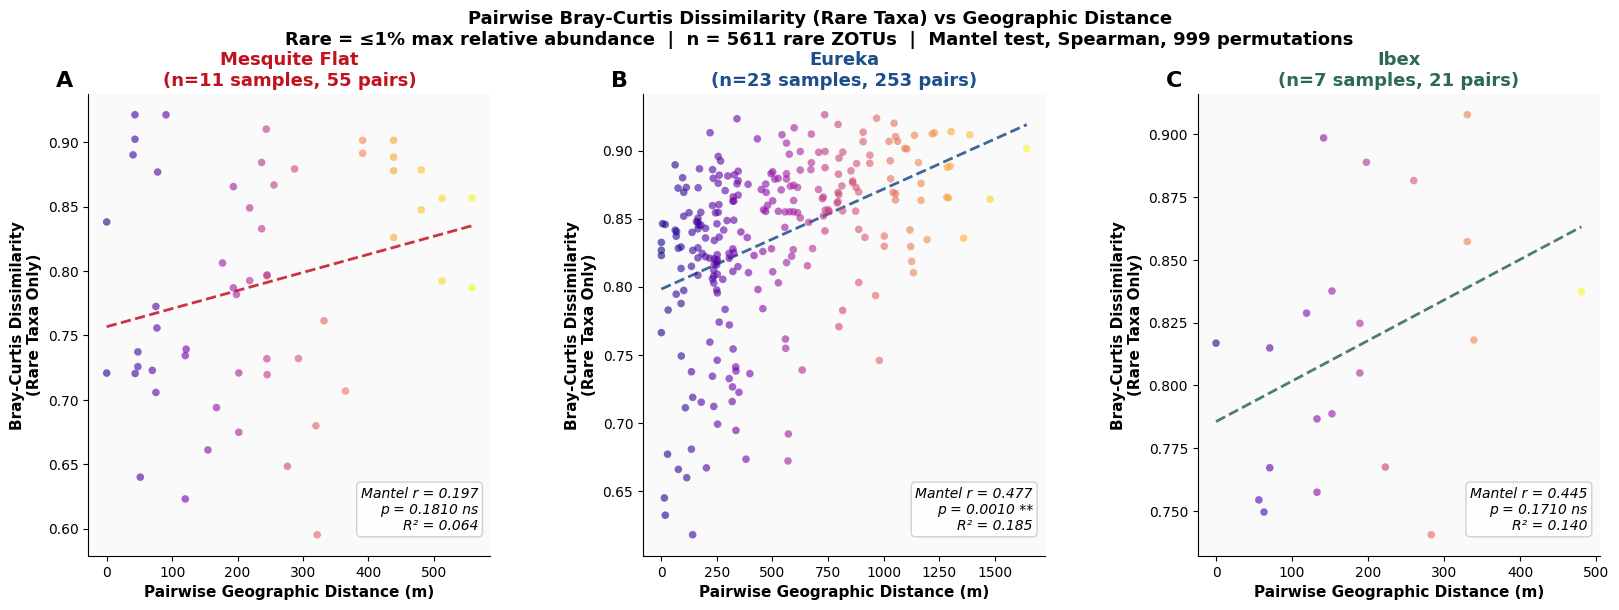

In [3]:
#mantel bray cutis on rare taxa and distnace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER PROKARYOTES
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

# ============================
# IDENTIFY RARE ZOTUs
# rare = never exceeds 1% in any single sample
# ============================
zotu_max      = otu.max(axis=0)
rare_zotus    = zotu_max[zotu_max <= 1.0].index
dominant_zotus = zotu_max[zotu_max >  1.0].index

otu_rare = otu[rare_zotus].copy()

print(f"\nRare ZOTUs (≤1% max):     {len(rare_zotus)}")
print(f"Dominant ZOTUs (>1% max): {len(dominant_zotus)}")
print(f"Rare OTU matrix:          {otu_rare.shape}")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

# ============================
# RUN PAIRWISE MANTEL
# rare taxa Bray-Curtis vs geographic distance
# ============================
def run_rare_mantel(field, sample_list, otu_rare,
                    coord_map, n_perm=999):

    samps = [s for s in sample_list
             if s in otu_rare.index and s in coord_map]
    n     = len(samps)

    print(f"\n{field} (n={n} samples)")

    if n < 4:
        print(f"  Insufficient samples — skipping")
        return None

    # geographic distance matrix
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    # bray-curtis on rare taxa only
    sub    = otu_rare.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    # mantel test
    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)

    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    print(f"  Mantel r = {r:.3f}  p = {p:.4f}  {sig}")

    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "p": p, "sig": sig,
        "samps": samps,
        "x_geo": x_geo,
        "y_bc":  y_bc,
        "n":     n
    }

# ============================
# RUN FOR ALL THREE FIELDS
# ============================
print("=" * 55)
print("PAIRWISE MANTEL — Rare Taxa Bray-Curtis")
print("vs Geographic Distance")
print(f"Rare = ≤1% max relative abundance in any sample")
print(f"n rare ZOTUs = {len(rare_zotus)}")
print("Spearman correlation, 999 permutations")
print("=" * 55)

results = {}
for field, slist in transects.items():
    results[field] = run_rare_mantel(
        field, slist, otu_rare, coord_map, n_perm=999)

# ============================
# FIGURE
# ============================
fields = [f for f in transects if results[f] is not None]

fig, axes = plt.subplots(
    1, len(fields),
    figsize=(6.5 * len(fields), 6),
    gridspec_kw={"wspace": 0.38})
fig.patch.set_facecolor("white")

if len(fields) == 1:
    axes = [axes]

panel_labels = "ABC"

for ax, field, panel_lbl in zip(axes, fields, panel_labels):
    res   = results[field]
    color = field_colors[field]

    x = res["x_geo"]
    y = res["y_bc"]

    # scatter coloured by distance
    ax.scatter(x, y, c=x, cmap="plasma",
               alpha=0.6, s=30, linewidths=0,
               vmin=x.min(), vmax=x.max(),
               zorder=3)

    # regression line
    slope, intercept, r_val, p_val, _ = linregress(x, y)
    r2   = r_val ** 2
    x_ln = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_ln, slope * x_ln + intercept,
            color=color, linewidth=2,
            linestyle="--", alpha=0.85)

    # stats box
    ax.text(0.97, 0.05,
            f"Mantel r = {res['r']:.3f}\n"
            f"p = {res['p']:.4f} {res['sig']}\n"
            f"R² = {r2:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10, style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc",
                      alpha=0.9))

    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")

    ax.set_title(
        f"{field}\n(n={res['n']} samples, "
        f"{len(x)} pairs)",
        fontsize=13, fontweight="bold",
        color=color)
    ax.set_xlabel("Pairwise Geographic Distance (m)",
                  fontsize=11, fontweight="bold")
    ax.set_ylabel("Bray-Curtis Dissimilarity\n(Rare Taxa Only)",
                  fontsize=11, fontweight="bold")
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

fig.suptitle(
    f"Pairwise Bray-Curtis Dissimilarity (Rare Taxa) "
    f"vs Geographic Distance\n"
    f"Rare = ≤1% max relative abundance  "
    f"|  n = {len(rare_zotus)} rare ZOTUs  "
    f"|  Mantel test, Spearman, 999 permutations",
    fontsize=13, fontweight="bold", y=1.02)

plt.show()


Prokaryotic ZOTUs: 5892
OTU matrix: 52 samples x 5892 ZOTUs

Subset sizes:
  All taxa:     5892 ZOTUs
  Rare only:    5611 ZOTUs
  Dominant:     283 ZOTUs
  Core only:    5834 ZOTUs (20 phyla)

PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance
Spearman correlation, 999 permutations

--- All Taxa ---
  Mesquite Flat   r=0.230  p=0.1310  ns
  Eureka          r=0.335  p=0.0020  **
  Ibex            r=0.594  p=0.0480  *

--- Rare Only ---
  Mesquite Flat   r=0.197  p=0.1710  ns
  Eureka          r=0.477  p=0.0010  **
  Ibex            r=0.445  p=0.1800  ns

--- Dominant ---
  Mesquite Flat   r=0.249  p=0.0840  ns
  Eureka          r=0.262  p=0.0090  **
  Ibex            r=0.480  p=0.0870  ns

--- Core Only ---
  Mesquite Flat   r=0.229  p=0.1090  ns
  Eureka          r=0.337  p=0.0020  **
  Ibex            r=0.594  p=0.0540  ns


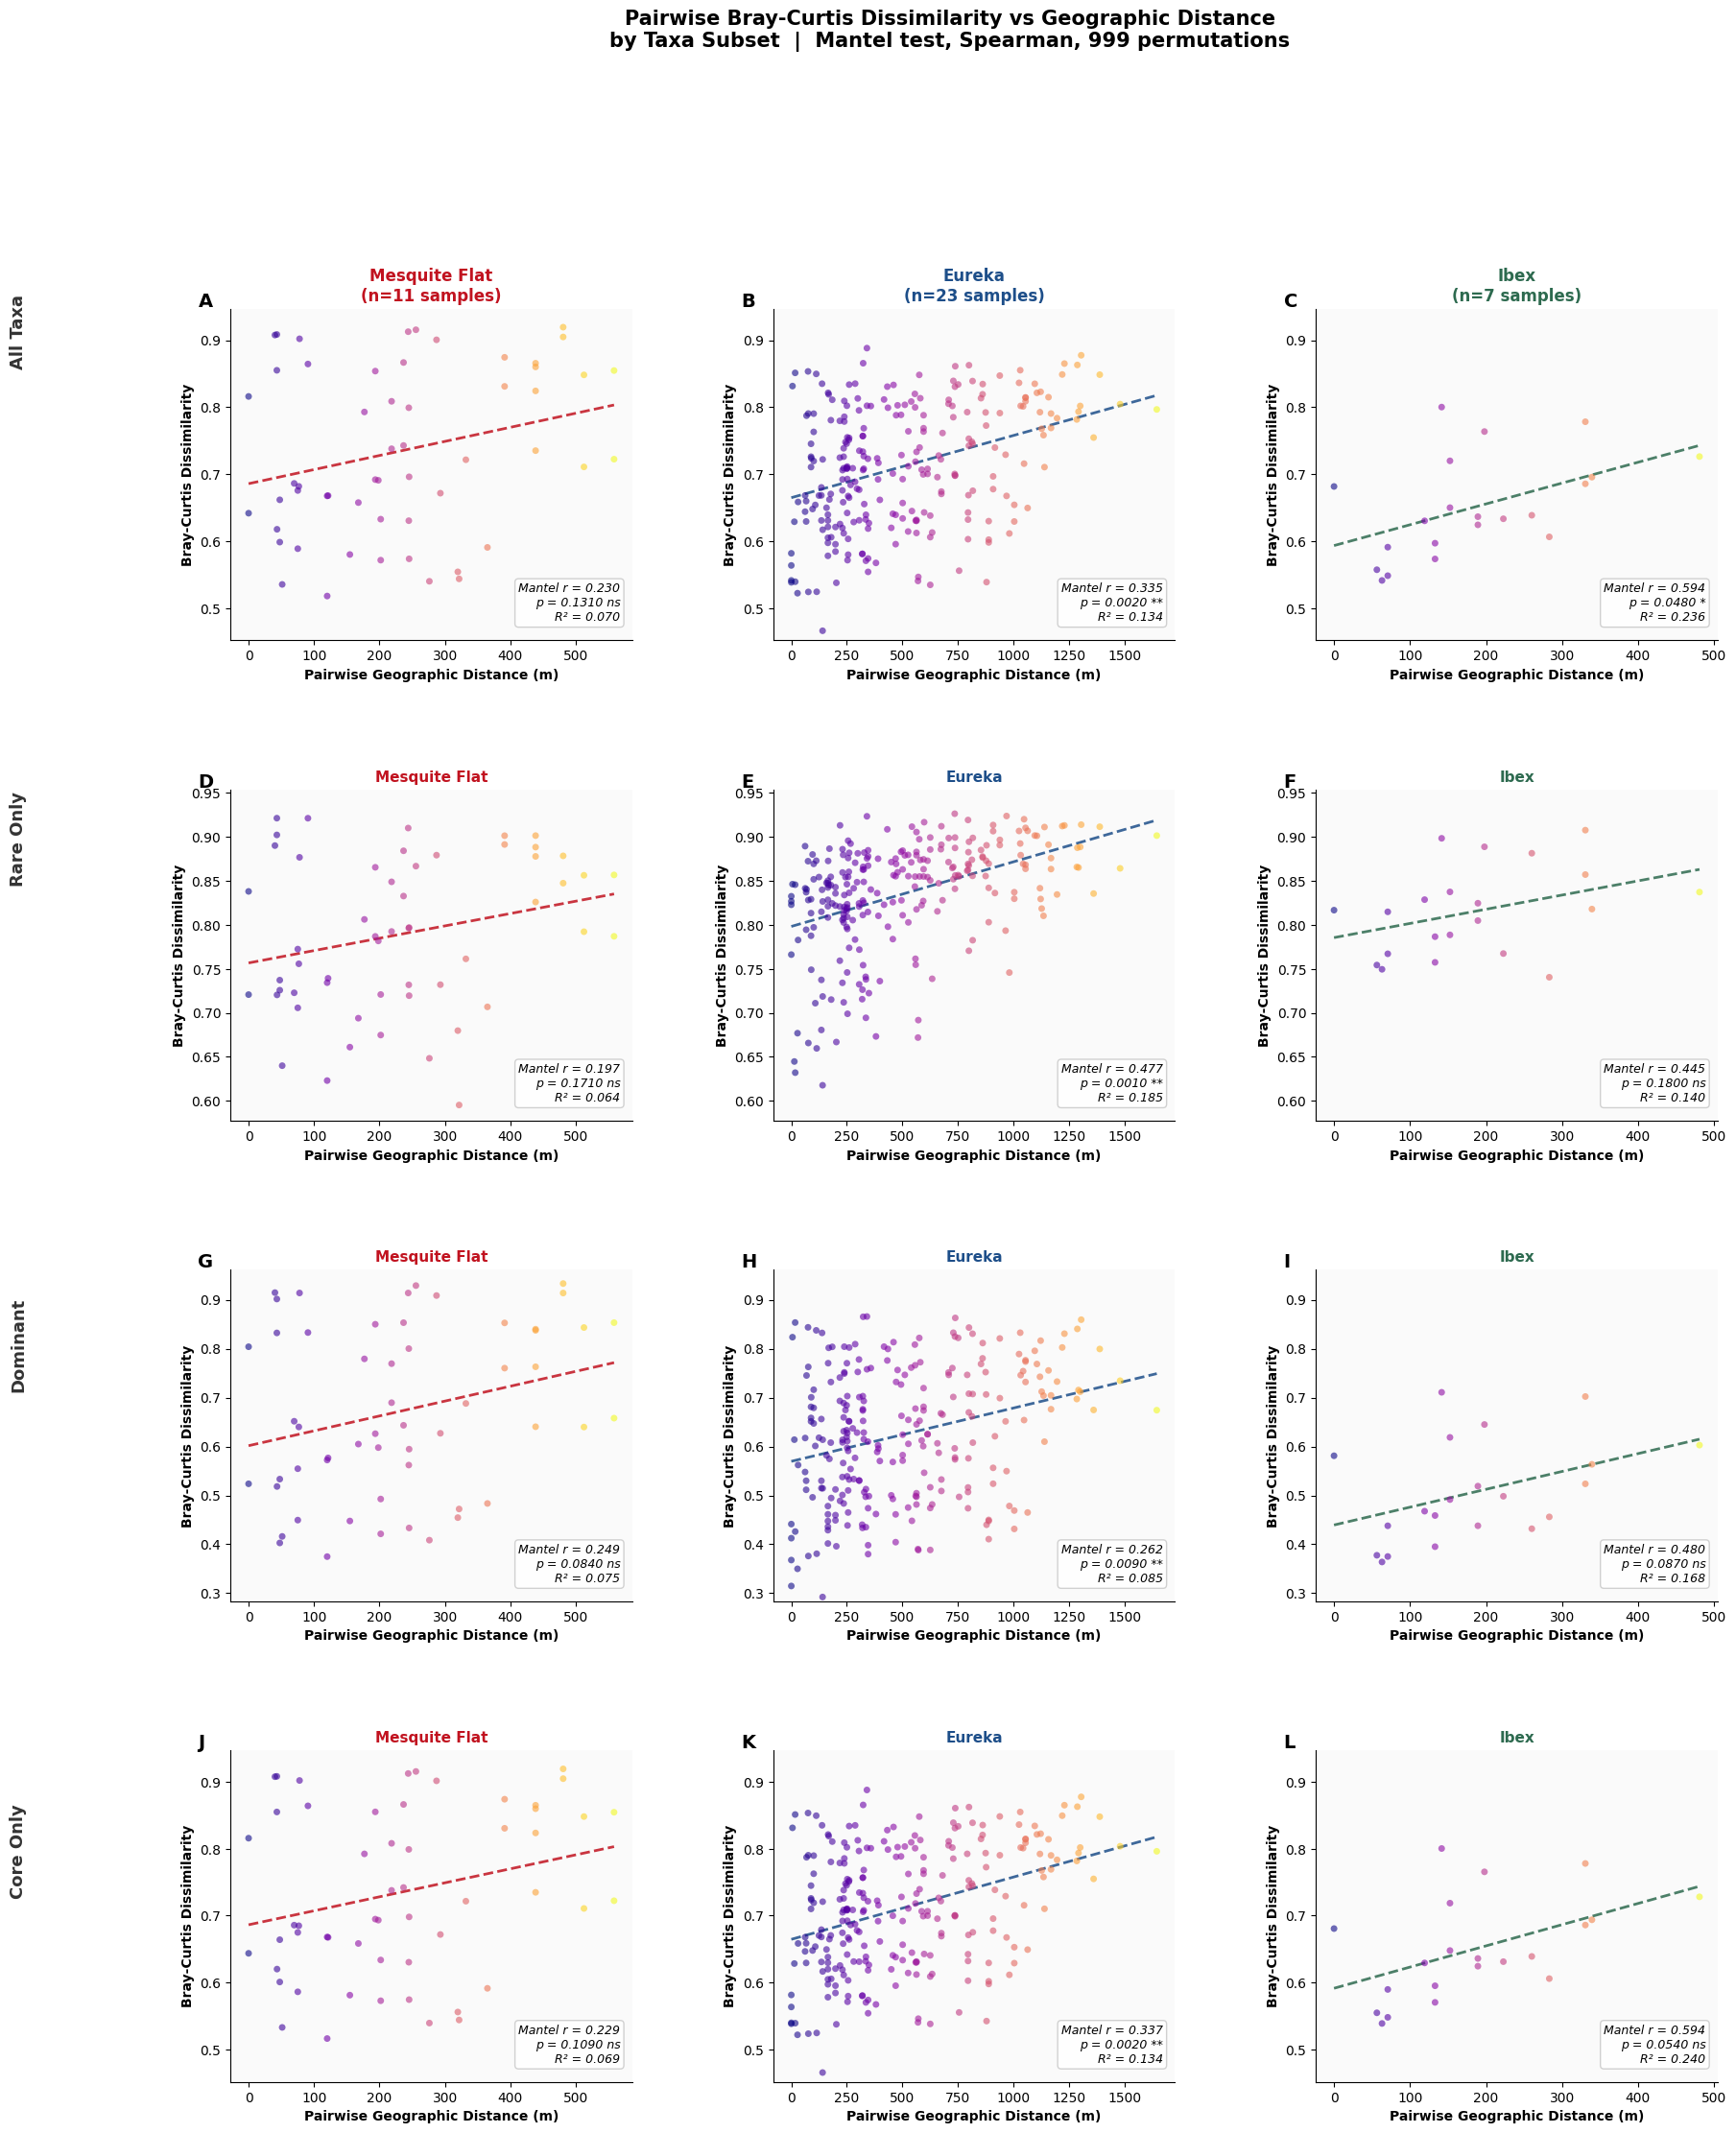

Saved: mantel_all_subsets_geo_distance.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER PROKARYOTES
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

# ============================
# RARE / DOMINANT SPLIT
# rare = never exceeds 1% in any single sample
# ============================
zotu_max       = otu.max(axis=0)
rare_zotus     = zotu_max[zotu_max <= 1.0].index
dominant_zotus = zotu_max[zotu_max >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence in all three fields
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols
                    if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols
                    if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols
                    if get_field(s) == "Ibex"]

phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_col)["Phylum"].to_dict()
core_zotus  = [z for z in otu.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# BUILD FOUR SUBSETS
# ============================
otu_all      = otu.copy()
otu_rare     = otu[rare_zotus].copy()
otu_dominant = otu[dominant_zotus].copy()
otu_core     = otu[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa:     {otu_all.shape[1]} ZOTUs")
print(f"  Rare only:    {otu_rare.shape[1]} ZOTUs")
print(f"  Dominant:     {otu_dominant.shape[1]} ZOTUs")
print(f"  Core only:    {otu_core.shape[1]} ZOTUs "
      f"({len(core_phyla)} phyla)")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

subsets = [
    ("All Taxa",     otu_all),
    ("Rare Only",    otu_rare),
    ("Dominant",     otu_dominant),
    ("Core Only",    otu_core),
]

# ============================
# MANTEL TEST FUNCTION
# ============================
def run_mantel(field, sample_list, otu_subset,
               coord_map, n_perm=999):

    samps = [s for s in sample_list
             if s in otu_subset.index and s in coord_map]
    n     = len(samps)

    if n < 4:
        return None

    # geographic distance matrix
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    # bray-curtis
    sub    = otu_subset.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    # mantel test
    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)

    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "p": p, "sig": sig,
        "samps": samps, "n": n,
        "x_geo": x_geo, "y_bc": y_bc,
    }

# ============================
# RUN ALL COMBINATIONS
# ============================
print("\n" + "="*60)
print("PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance")
print("Spearman correlation, 999 permutations")
print("="*60)

all_results = {}
for subset_name, otu_sub in subsets:
    print(f"\n--- {subset_name} ---")
    all_results[subset_name] = {}
    for field, slist in transects.items():
        res = run_mantel(field, slist, otu_sub,
                         coord_map, n_perm=999)
        all_results[subset_name][field] = res
        if res:
            print(f"  {field:<15} "
                  f"r={res['r']:.3f}  "
                  f"p={res['p']:.4f}  "
                  f"{res['sig']}")
        else:
            print(f"  {field:<15} insufficient samples")

# ============================
# FIGURE
# 4 rows (subsets) x 3 cols (fields)
# ============================
subset_names = [s for s, _ in subsets]
field_names  = list(transects.keys())

fig, axes = plt.subplots(
    4, 3, figsize=(20, 24),
    gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.patch.set_facecolor("white")

panel_labels = "ABCDEFGHIJKL"
panel_idx    = 0

# compute shared y limits per row
y_lims = {}
for subset_name in subset_names:
    all_y = []
    for field in field_names:
        res = all_results[subset_name].get(field)
        if res:
            all_y.extend(res["y_bc"].tolist())
    if all_y:
        y_lims[subset_name] = (
            min(all_y) * 0.97,
            max(all_y) * 1.03
        )
    else:
        y_lims[subset_name] = (0, 1)

for ri, subset_name in enumerate(subset_names):
    for fi, field in enumerate(field_names):
        ax    = axes[ri, fi]
        color = field_colors[field]
        res   = all_results[subset_name].get(field)

        # panel label
        ax.text(-0.08, 1.05, panel_labels[panel_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")

        if res is None:
            ax.set_title(f"{field}\n(no data)",
                         fontsize=11, color=color)
            ax.set_visible(True)
            panel_idx += 1
            continue

        x = res["x_geo"]
        y = res["y_bc"]

        # scatter coloured by distance
        ax.scatter(x, y, c=x, cmap="plasma",
                   alpha=0.6, s=25, linewidths=0,
                   vmin=x.min(), vmax=x.max(),
                   zorder=3)

        # regression line + stats
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        r2   = r_val ** 2
        x_ln = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_ln, slope * x_ln + intercept,
                color=color, linewidth=2,
                linestyle="--", alpha=0.85)

        ax.text(0.97, 0.05,
                f"Mantel r = {res['r']:.3f}\n"
                f"p = {res['p']:.4f} {res['sig']}\n"
                f"R² = {r2:.3f}",
                transform=ax.transAxes,
                ha="right", va="bottom",
                fontsize=9, style="italic",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="#cccccc",
                          alpha=0.9))

        # titles — only top row gets field name
        if ri == 0:
            ax.set_title(
                f"{field}\n(n={res['n']} samples)",
                fontsize=12, fontweight="bold",
                color=color)
        else:
            ax.set_title(
                f"{field}",
                fontsize=11, fontweight="bold",
                color=color)

        ax.set_xlabel("Pairwise Geographic Distance (m)",
                      fontsize=10, fontweight="bold")
        ax.set_ylabel("Bray-Curtis Dissimilarity",
                      fontsize=10, fontweight="bold")
        ax.set_ylim(y_lims[subset_name])
        ax.tick_params(labelsize=10)
        ax.set_facecolor("#fafafa")
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)

        panel_idx += 1

# ============================
# ROW LABELS — subset names
# ============================
row_y_positions = [0.87, 0.65, 0.43, 0.21]
for label, ypos in zip(subset_names, row_y_positions):
    fig.text(0.01, ypos, label,
             fontsize=13, fontweight="bold",
             va="center", rotation=90,
             color="#333333")

fig.suptitle(
    "Pairwise Bray-Curtis Dissimilarity vs Geographic Distance\n"
    "by Taxa Subset  |  Mantel test, Spearman, 999 permutations",
    fontsize=15, fontweight="bold", y=1.01)


plt.show()
